In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings

from AOSCMcoupling.convergence_checker import relative_error

In [2]:
plt.style.use('article.mplstyle')

In [3]:
class OASISPreprocessor:
    def __init__(
        self, origin: pd.Timestamp = None, time_shift: pd.Timedelta = pd.Timedelta(0)
    ):
        """Constructor.

        :param origin: start date (+ time) of the simulation
        :type origin: pd.Timestamp
        :param time_shift: time shift to apply for local time, default: 0
        :type time_shift: pd.Timedelta, optional
        """
        self.origin = origin
        self.time_shift = time_shift

    def preprocess(self, ds: xr.Dataset) -> xr.DataArray:
        """Preprocess function for use with `xr.open_mfdataset()`.

        :param ds: dataset as loaded from disk
        :type ds: xr.Dataset
        :return: preprocessed DataArray (only one variable!)
        :rtype: xr.DataArray
        """
        ds = ds.isel(ny=0, nx=0)

        source_file = Path(ds.encoding["source"])
        iteration = int(source_file.parent.name.split("_")[-1])
        ds = ds.expand_dims(
            iteration=[iteration],
        )
        time_data = np.array(ds.time.data, dtype="timedelta64[s]")
        ds = ds.assign_coords(time=ds.time - ds.time[0])

        if self.origin is not None:
            time_data = np.array(ds.time.data, dtype="timedelta64[s]")
            ds = ds.assign_coords(time=self.origin + time_data + self.time_shift)
        return ds

In [4]:
preprocessor = OASISPreprocessor(pd.Timestamp("2014-07-01"), pd.Timedelta(-7, "h"))
exp_id = "PAPA"
max_iters = 15
start_dates = pd.date_range(
        pd.Timestamp("2014-07-01 00:00:00"),
        pd.Timestamp("2014-07-28 18:00:00"),
        freq="6h",
    )
start_dates = start_dates
coupling_vars = [
    "A_Qns_mix",
]



nlevels_list = [31, 75]
marker_list = []
factors = []
for nlevels in nlevels_list:
    base_dir = Path(f"PAPA/papa_1H_L{nlevels}")
    factors_nlev = []
    for start_date in start_dates:
        start_date_string = f"{start_date.date()}_{start_date.hour:02}"
        output_dir = base_dir / start_date_string
        netcdf_files = [file for file in output_dir.glob(f"{exp_id}_*/*.nc")]
        oasis_files = [
            file for file in netcdf_files if any(cv in file.name for cv in coupling_vars)
        ]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ds = xr.open_mfdataset(oasis_files, preprocess=preprocessor.preprocess)
        rel_errors_inf = relative_error(
            ds, ds.isel(iteration=-1), ds.isel(iteration=0), ord=np.inf
        )

        factor_Qns = rel_errors_inf.A_Qns_mix.sel(iteration=np.arange(3, 10)) / rel_errors_inf.A_Qns_mix.sel(iteration=np.arange(1, 8)).data
        factors_nlev.append(float(np.mean(factor_Qns[:5])))
    factors.append(factors_nlev)




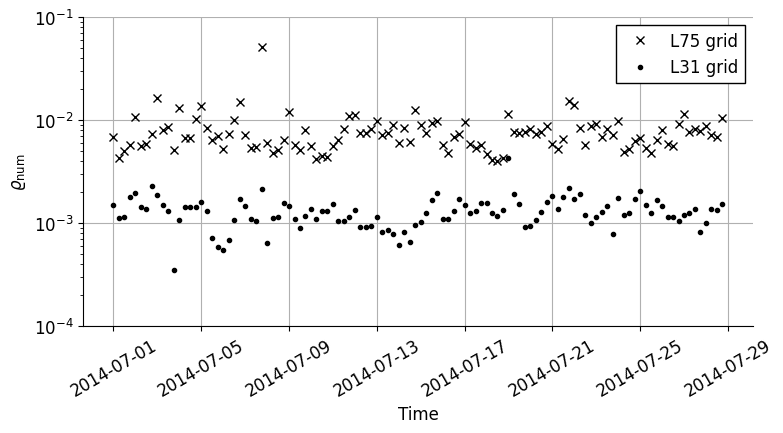

In [9]:
fig, ax = plt.subplots()
fig.set(figwidth=8, figheight=4.5)
    
ax.semilogy(start_dates, factors[1], marker="x", ls="none", label=f"L{nlevels_list[1]} grid")
ax.semilogy(start_dates, factors[0], marker=".", ls="none", label=f"L{nlevels_list[0]} grid")
ax.set(xlabel="Time", ylabel=r"$\varrho_\mathrm{num}$", ylim=[1e-4, 1e-1]);
ax.tick_params(axis='x', labelrotation=30)
ax.grid();
ax.legend()
fig.savefig("cf_over_time_1month.pdf")